# Retention Cohorts 
lets say we are doing this analysis on : 1 st Jan 2012

In [1]:

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
pd.set_option('display.max_columns', 999)

In [2]:
df = pd.read_excel('../k-means clustering/online_retail_II.xlsx', sheet_name='Year 2009-2010', index_col=0)


In [3]:
df.head(4)

,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
Invoice,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom


In [4]:
# removing null customer Id and removing the ones that are 0 
df = df[df['Customer ID'].notnull()]
df = df[df['Customer ID'] != 0]

In [5]:
df['Customer ID'].value_counts()

Customer ID
14911.0    5710
17841.0    5114
14606.0    3927
14156.0    2710
12748.0    2665
           ... 
17925.0       1
16995.0       1
14576.0       1
18113.0       1
13270.0       1
Name: count, Length: 4383, dtype: int64

In [6]:
## checking if all customer ids are 5 digit numbers

is_five_digit = df['Customer ID'].astype('Int64').astype(str).str.match(r'^\d{5}$')
print(is_five_digit.value_counts(dropna=False))

# show any that don't match
df.loc[~is_five_digit, 'Customer ID'].unique()

Customer ID
True    417534
Name: count, dtype: int64


array([], dtype=float64)

In [7]:
# filtering to price and quantity greater than 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [8]:
# cheking if duplicates exist in the data
print("Total rows:", len(df))
print("Distinct rows:", df.drop_duplicates().shape[0])


Total rows: 407664
Distinct rows: 400903


In [9]:
# looking at the duplicates in the data
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(5)


,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
Invoice,,,,,,,
490063,10002,INFLATABLE POLITICAL GLOBE,1,2009-12-03 13:49:00,0.85,17271.0,United Kingdom
490063,10002,INFLATABLE POLITICAL GLOBE,1,2009-12-03 13:49:00,0.85,17271.0,United Kingdom
500336,10002,INFLATABLE POLITICAL GLOBE,1,2010-03-07 13:48:00,0.85,17589.0,United Kingdom
500336,10002,INFLATABLE POLITICAL GLOBE,1,2010-03-07 13:48:00,0.85,17589.0,United Kingdom
523019,10002,INFLATABLE POLITICAL GLOBE,1,2010-09-20 11:24:00,0.85,17811.0,United Kingdom


In [10]:
# dropping duplicates
df = df.drop_duplicates()


In [11]:
len(df)
df['InvoiceDate'].min(), df['InvoiceDate'].max()


(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

ok now there are various types of cohorts like - time based , size based and segment based 
since we are doing retention analysis we will use time based cohorts 



In [12]:
# adding some more columns 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['revenue'] = df['Price'] * df['Quantity']


In [13]:
df['first_purchase_date'] = df.groupby('Customer ID')['InvoiceDate'].transform('min')

In [14]:
# df[df['Customer ID'] == 16657.0]
df['cohort_date'] = pd.to_datetime(dict(
    year=df['first_purchase_date'].dt.year,
    month=df['first_purchase_date'].dt.month,
    day=1
))


In [15]:
df.head(3)

,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,year,month,day,revenue,first_purchase_date,cohort_date
Invoice,,,,,,,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,83.4,2009-12-01 07:45:00,2009-12-01
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01


In [16]:
# calculating cohort dates
df['cohort_year'] = df['first_purchase_date'].dt.year
df['cohort_month'] = df['first_purchase_date'].dt.month 
df['cohort_day'] = df['first_purchase_date'].dt.day



In [17]:
df.head(2)

,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,year,month,day,revenue,first_purchase_date,cohort_date,cohort_year,cohort_month,cohort_day
Invoice,,,,,,,,,,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,83.4,2009-12-01 07:45:00,2009-12-01,2009,12,1
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01,2009,12,1


In [18]:
# calculate cohort index
df['cohort_index'] = (df['year'] - df['cohort_year']) * 12 + (df['month'] - df['cohort_month']) + 1


In [19]:
# this is essentia;y our cohort retention dataset
df.head(4)


,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,year,month,day,revenue,first_purchase_date,cohort_date,cohort_year,cohort_month,cohort_day,cohort_index
Invoice,,,,,,,,,,,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,83.4,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,100.8,2009-12-01 07:45:00,2009-12-01,2009,12,1,1


In [20]:
## exploring how it looks like grouped by cohorts
grouped = df.groupby(['Customer ID', 'year','month']).agg(
    revenue=('revenue', 'sum'),
    cohort_index=('cohort_index', 'max'),
    first_purchase_date=('first_purchase_date', 'max'),
    cohort_date=('cohort_date', 'max')
).reset_index()


In [21]:
## exploring how it looks like grouped by cohorts
grouped[grouped['Customer ID']== 16657]

,Customer ID,year,month,revenue,cohort_index,first_purchase_date,cohort_date


In [22]:
# checkpoint 
retention_dataset = df.copy()

In [23]:
retention_dataset.head(1)

,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,year,month,day,revenue,first_purchase_date,cohort_date,cohort_year,cohort_month,cohort_day,cohort_index
Invoice,,,,,,,,,,,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,83.4,2009-12-01 07:45:00,2009-12-01,2009,12,1,1


## building the retention cohort (N month retention)
we also hve something called as n day rolling retention which we can build


In [24]:
retention_dataset.head(5)

,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,year,month,day,revenue,first_purchase_date,cohort_date,cohort_year,cohort_month,cohort_day,cohort_index
Invoice,,,,,,,,,,,,,,,,,
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,83.4,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,81.0,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,100.8,2009-12-01 07:45:00,2009-12-01,2009,12,1,1
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,30.0,2009-12-01 07:45:00,2009-12-01,2009,12,1,1


In [25]:
cohort_pivot_dataset = retention_dataset.groupby(['cohort_date', 'cohort_index'])['Customer ID'].nunique().reset_index()

cohort_pivot = cohort_pivot_dataset.pivot(index='cohort_date',columns='cohort_index', values='Customer ID')

In [26]:
cohort_pivot

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_date,,,,,,,,,,,,,
2009-12-01,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
2010-01-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
2010-02-01,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
2010-03-01,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04-01,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
2010-05-01,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06-01,270.0,47.0,51.0,55.0,62.0,77.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,162.0,33.0,48.0,52.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
cohort_size = cohort_pivot.iloc[:, 0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100


In [28]:
retention_pct
retention_pct.style.format("{:.0f}%")


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_date,,,,,,,,,,,,,
2009-12-01 00:00:00,100%,35%,33%,43%,38%,36%,38%,34%,34%,36%,42%,50%,25%
2010-01-01 00:00:00,100%,21%,31%,31%,26%,30%,26%,23%,28%,32%,30%,10%,nan%
2010-02-01 00:00:00,100%,24%,22%,29%,25%,20%,19%,29%,25%,28%,7%,nan%,nan%
2010-03-01 00:00:00,100%,19%,23%,24%,23%,20%,25%,30%,28%,8%,nan%,nan%,nan%
2010-04-01 00:00:00,100%,19%,19%,16%,18%,22%,28%,26%,7%,nan%,nan%,nan%,nan%
2010-05-01 00:00:00,100%,16%,17%,17%,18%,26%,21%,8%,nan%,nan%,nan%,nan%,nan%
2010-06-01 00:00:00,100%,17%,19%,20%,23%,29%,7%,nan%,nan%,nan%,nan%,nan%,nan%
2010-07-01 00:00:00,100%,16%,18%,30%,29%,10%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2010-08-01 00:00:00,100%,20%,30%,32%,12%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


In [29]:
combined = cohort_pivot.astype('Int64').astype(str) + ' (' + retention_pct.round(0).astype('Int64').astype(str) + '%)'


In [30]:
combined


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_date,,,,,,,,,,,,,
2009-12-01,955 (100%),337 (35%),319 (33%),406 (43%),363 (38%),343 (36%),360 (38%),327 (34%),321 (34%),346 (36%),403 (42%),473 (50%),237 (25%)
2010-01-01,383 (100%),79 (21%),119 (31%),117 (31%),101 (26%),115 (30%),99 (26%),88 (23%),107 (28%),122 (32%),116 (30%),38 (10%),NaN
2010-02-01,374 (100%),89 (24%),84 (22%),109 (29%),92 (25%),75 (20%),72 (19%),107 (29%),95 (25%),103 (28%),27 (7%),NaN,NaN
2010-03-01,443 (100%),84 (19%),102 (23%),107 (24%),103 (23%),90 (20%),109 (25%),134 (30%),122 (28%),35 (8%),NaN,NaN,NaN
2010-04-01,294 (100%),57 (19%),57 (19%),48 (16%),54 (18%),66 (22%),81 (28%),77 (26%),20 (7%),NaN,NaN,NaN,NaN
2010-05-01,254 (100%),40 (16%),43 (17%),44 (17%),45 (18%),65 (26%),54 (21%),20 (8%),NaN,NaN,NaN,NaN,NaN
2010-06-01,270 (100%),47 (17%),51 (19%),55 (20%),62 (23%),77 (29%),18 (7%),NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,186 (100%),29 (16%),34 (18%),55 (30%),54 (29%),19 (10%),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,162 (100%),33 (20%),48 (30%),52 (32%),19 (12%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


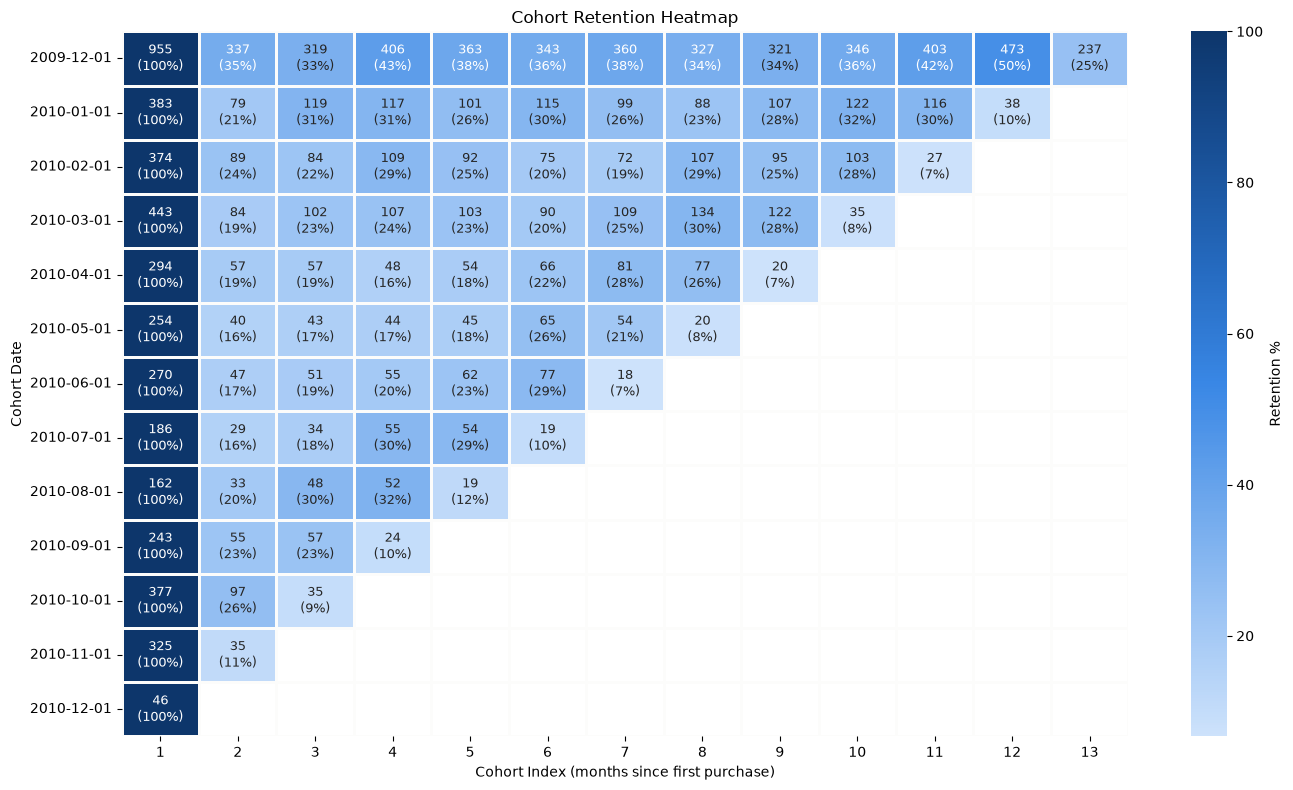

In [31]:
from matplotlib.colors import LinearSegmentedColormap

blue_ramp = [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b"
]
cmap = LinearSegmentedColormap.from_list("sequential_blue", blue_ramp)

combined = (
    cohort_pivot.astype('Int64').astype(str)
    + '\n('
    + retention_pct.round(0).astype('Int64').astype(str)
    + '%)'
)
combined = combined.where(cohort_pivot.notna(), '')

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_pct,
    annot=combined.values,
    fmt='',
    cmap=cmap,
    linewidths=2,
    linecolor="#fcfcfb",
    annot_kws={'size': 9},
    yticklabels=retention_pct.index.strftime('%Y-%m-%d'),
    cbar_kws={'label': 'Retention %'}
)
plt.title('Cohort Retention Heatmap')
plt.xlabel('Cohort Index (months since first purchase)')
plt.ylabel('Cohort Date')
plt.tight_layout()
plt.show()



In [ ]:
## how can we connect clusters to retention
